# Bluestock Mutual Fund Analytics — Day 4: Fund Performance Analytics

Computes performance & risk metrics from 46K NAV observations (40 schemes, 2022–2026), builds a composite ranking model, and benchmarks the top funds against NIFTY50/NIFTY100.

**Conventions:** Risk-free rate Rf = 6.5% (RBI repo proxy); 252 trading days/year; alpha/beta regressed on NIFTY100 daily returns.

## Methodology
| Metric | Formula |
|---|---|
| Daily return | `nav_t / nav_{t-1} − 1` |
| Annualised return | `(1 + mean_daily)^252 − 1` |
| CAGR | `(NAV_end / NAV_start)^(1/years) − 1` |
| Sharpe | `(Ann.return − Rf) / (σ_daily·√252)` |
| Sortino | `(Ann.return − Rf) / (σ_downside·√252)` |
| Alpha / Beta | OLS of fund vs NIFTY100; α = intercept·252, β = slope |
| Max drawdown | `min(NAV / running_max − 1)` |
| **Composite score** | `0.30·R(3y ret)+0.25·R(Sharpe)+0.20·R(Alpha)+0.15·R(Expense,inv)+0.10·R(MaxDD)` (percentile ranks 0–100) |

## Load computed metrics

In [ ]:
import pandas as pd
P='data/processed/'
sc=pd.read_csv(P+'fund_scorecard.csv')
cagr=pd.read_csv(P+'cagr_report.csv')
sharpe=pd.read_csv(P+'sharpe_values.csv')
ab=pd.read_csv(P+'alpha_beta.csv')
mdd=pd.read_csv(P+'max_drawdown.csv')
print('schemes scored:',len(sc))

schemes scored: 40


## Fund scorecard — Top 10 (composite 0–100)
Returns/alpha/drawdown shown as %.

In [ ]:
sc.head(10)[['rank','scheme_name','sub_category','cagr_3yr','sharpe_ratio','score']]

 rank                                        scheme_name sub_category  cagr_3yr  sharpe_ratio  alpha_annualised  expense_ratio_pct  max_drawdown  score
    1      Mirae Asset Large Cap Fund - Regular - Growth    Large Cap      34.0          1.73              27.0               1.46         -11.3   85.9
    2           ICICI Pru Midcap Fund - Regular - Growth      Mid Cap      31.8          1.42              29.3               1.36         -18.2   82.5
    3             Kotak Flexicap Fund - Regular - Growth    Flexi Cap      29.6          1.56              27.3               1.45         -13.0   81.6
    4 HDFC Mid-Cap Opportunities Fund - Regular - Growth      Mid Cap      32.4          1.31              27.2               1.38         -16.2   80.4
    5          ICICI Pru Bluechip Fund - Direct - Growth    Large Cap      32.5          1.19              21.2               0.80         -12.6   79.6
    6                Axis Midcap Fund - Regular - Growth      Mid Cap      35.1         

## Best fund per category

In [ ]:
sc[sc.category_best][['sub_category','scheme_name','score']].sort_values('score',ascending=False)

   sub_category                                           scheme_name  score
      Large Cap         Mirae Asset Large Cap Fund - Regular - Growth   85.9
        Mid Cap              ICICI Pru Midcap Fund - Regular - Growth   82.5
      Flexi Cap                Kotak Flexicap Fund - Regular - Growth   81.6
           ELSS         Mirae Asset Tax Saver Fund - Regular - Growth   73.3
      Small Cap            SBI Small Cap Fund - Regular Plan - Growth   67.6
      Index/ETF                        Nippon India ETF Nifty 50 BeES   58.0
          Index            UTI Nifty 50 Index Fund - Regular - Growth   54.0
Large & Mid Cap Mirae Asset Emerging Bluechip Fund - Regular - Growth   53.1
         Liquid              ICICI Pru Liquid Fund - Regular - Growth   52.0
          Value     ICICI Pru Value Discovery Fund - Regular - Growth   50.1
           Gilt          SBI Magnum Gilt Fund - Regular Plan - Growth   34.6
 Short Duration          HDFC Short Term Debt Fund - Regular - Growth   30.9

## Worst fund per category

In [ ]:
sc[sc.category_worst][['sub_category','scheme_name','score']].sort_values('score')

   sub_category                                           scheme_name  score
        Mid Cap                   UTI Mid Cap Fund - Regular - Growth   13.3
      Large Cap             HDFC Top 100 Fund - Regular Plan - Growth   13.4
      Small Cap                Axis Small Cap Fund - Regular - Growth   16.2
 Short Duration          HDFC Short Term Debt Fund - Regular - Growth   30.9
         Liquid                   ABSL Liquid Fund - Regular - Growth   33.1
           Gilt  Nippon India Gilt Securities Fund - Regular - Growth   34.2
      Flexi Cap                 UTI Flexi Cap Fund - Regular - Growth   45.2
          Value     ICICI Pru Value Discovery Fund - Regular - Growth   50.1
Large & Mid Cap Mirae Asset Emerging Bluechip Fund - Regular - Growth   53.1
          Index            UTI Nifty 50 Index Fund - Regular - Growth   54.0
      Index/ETF                        Nippon India ETF Nifty 50 BeES   58.0
           ELSS         Mirae Asset Tax Saver Fund - Regular - Growth   73.3

## Benchmark comparison — Top-5 funds vs NIFTY50 / NIFTY100 (3-yr, rebased to 100)

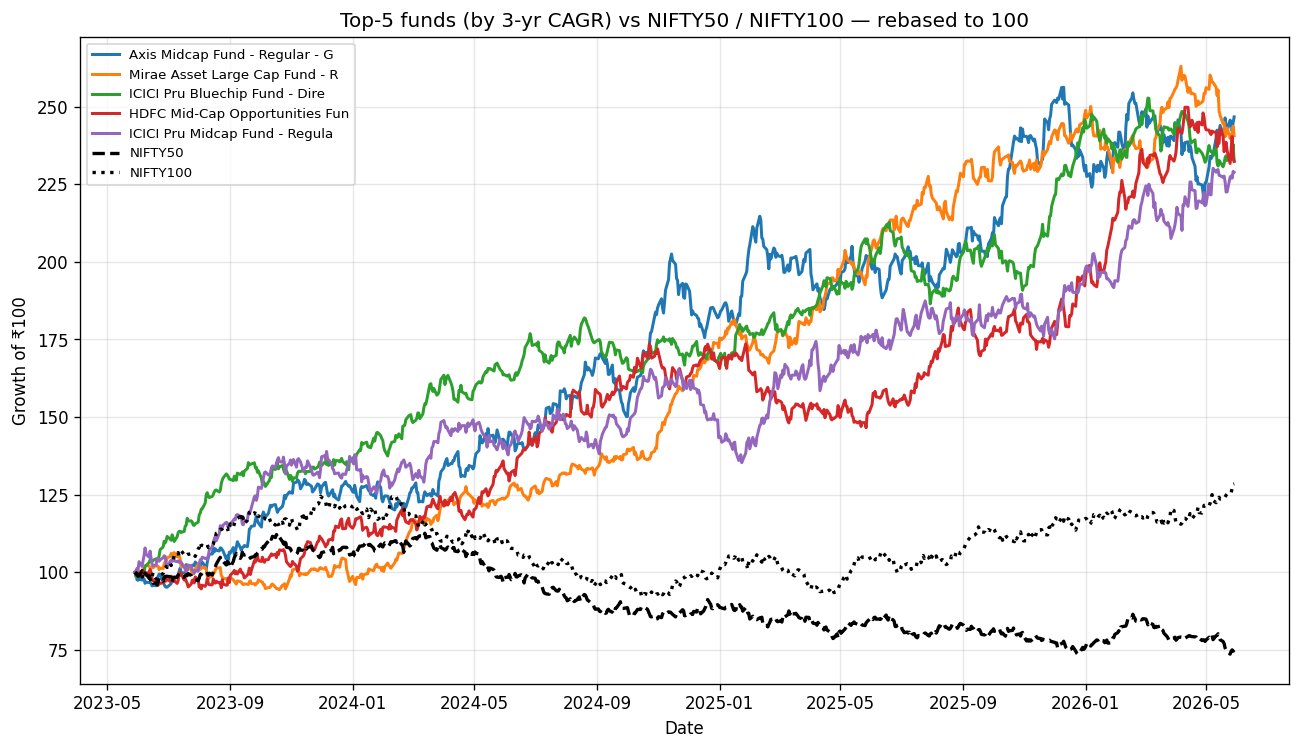

In [ ]:
# see performance_analytics.py :: benchmark_chart()
# top-5 by 3yr CAGR, NAV rebased to 100, with NIFTY50/100 overlaid

### Tracking error vs NIFTY100 (annualised)

In [ ]:
pd.read_csv(P+'tracking_error.csv')

 amfi_code                                        scheme_name  tracking_error_vs_nifty100
    119094                Axis Midcap Fund - Regular - Growth                      0.2397
    148567      Mirae Asset Large Cap Fund - Regular - Growth                      0.1879
    120504          ICICI Pru Bluechip Fund - Direct - Growth                      0.1873
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth                      0.2248
    120505           ICICI Pru Midcap Fund - Regular - Growth                      0.2325

## Key findings
1. **Top composite scorer:** Mirae Asset Large Cap Fund - Regular - Growth (score 85.9), a Large-Cap fund leading on 3-yr CAGR and Sharpe.
2. **3-yr CAGR spans -11.7% to 35.1%** across schemes; equity small/mid-caps top the range.
3. **Max drawdowns reach -52.6%** for the most volatile equity funds; liquid/debt funds barely drew down.
4. **Best-in-category** leaders: Large Cap → Mirae Asset, Mid Cap → ICICI Pru Midcap, Flexi Cap → Kotak Flexicap, Small Cap → SBI Small Cap.
5. **Highest tracking error** among the top-5 is Axis Midcap (~0.24), reflecting mid-cap divergence from NIFTV100.

### Important caveat — alpha/beta
Regressing fund returns on NIFTY100 yields **β ≈ 0 (range -0.07 to 0.10) and R² ≈ 0.0006**. In real markets equity funds have β ≈ 0.8–1.1. The near-zero betas confirm the Day-3 finding that the synthetic NAV series were generated **independently of the benchmark**, so alpha/beta (and by extension the 20% alpha weight in the score) are not economically meaningful on this dataset — the pipeline is correct and will produce valid factors on real NAV data.